##Lets explore 1st ODE Dynamic Systems


Text(0.5, 1.0, 'Analytical Solution (Cooling)')

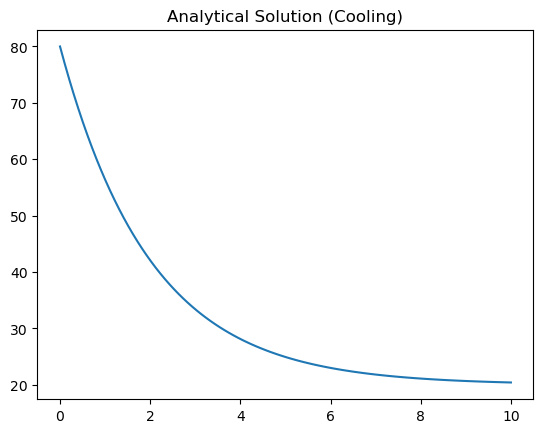

In [6]:
# Temperature Example 
import numpy as np 
import matplotlib.pyplot as plt 

t = np.linspace(0,10,100)

T_env = 20 
T0 = 80 
k = 0.5

#Analytical Solution 
T = T_env + (T0 - T_env) * np.exp(-k*t) #there is a time cosntatn (suspectde here) that is dependent on k 

plt.plot(t, T)
plt.title("Analytical Solution (Cooling)") #still has a time constanst, should see a decay to 20 degrees 

Text(0.5, 1.0, 'Analytical vs Numerical')

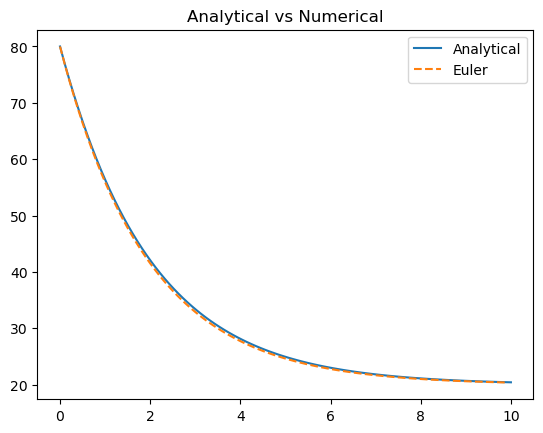

In [7]:
#Numerical Solution (Euler Method)
dt = 0.1 #we want to find th eplot in intervals of 0.1, per Eulers method) 
t_num = np.arange(0,10,dt)

T_num = np.zeros_like(t_num) #what is this?
T_num[0] = T0 

for i in range(len(t_num)-1): #Euler method here
    dTdt = -k * (T_num[i] - T_env) 
    T_num[i+1] = T_num[i] + dt*dTdt

plt.plot(t,T,label = "Analytical") #as the dt beomes infintesimaly smaller, the closer and closer we get to the analytical line we generated previously
plt.plot(t_num, T_num, '--', label="Euler") #making it dotted) 
plt.legend()
plt.title("Analytical vs Numerical") 

In [ ]:
#Numerical method via Python 
from scipy.integrate import solve_ivp #ivp stands for initial value problem

def model(t,T):
    return -k * (T-T_env)


sol = solve_ivp(model, [0,10],(T0),t_eval = t) #you need the model, the range (0 to 10), and the last bit i dk 
#by default, it uses range/kutta 4th/5th order

plt.plot(t,T,label = "Analytical") #as the dt beomes infintesimaly smaller, the closer and closer we get to the analytical line we generated previously
plt.plot(sol.t, sol.y, '--', label="solve_ivp") #making it dotted) 
plt.legend()
plt.title("Analytical vs Numerical") 


Text(0.5, 1.0, 'Analytical vs Numerical')

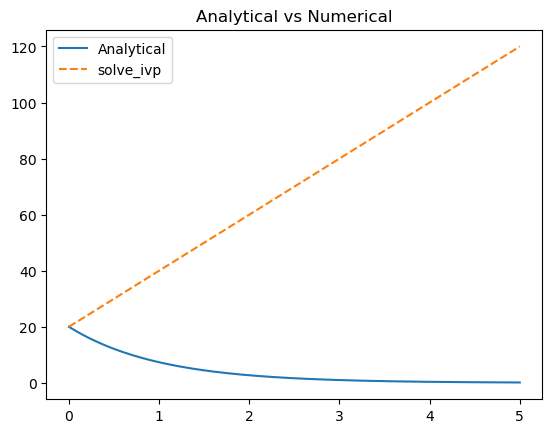

In [13]:
#On our own: Will be testing the ivp, by changing the model to something else 
from scipy.integrate import solve_ivp #ivp stands for initial value problem
Vin = 0
V0 = 20  
R = 1000
C = 0.001
t = np.linspace(0,5,200)

tau = R * C #analytical solution
V = Vin + (V0 - Vin)*np.exp(-t/tau)

def rc_model(t,V): #imperial solition
    return 1/(R * C) * (V0 - Vin)  


sol = solve_ivp(rc_model, [0,20],[V0],t_eval = t) #you need the model, the range (0 to 10), and the last bit i dk 
#by default, it uses range/kutta 4th/5th order

plt.plot(t,V,label = "Analytical") #as the dt beomes infintesimaly smaller, the closer and closer we get to the analytical line we generated previously
plt.plot(sol.t, sol.y[0], '--', label="solve_ivp") #making it dotted) 
plt.legend()
plt.title("Analytical vs Numerical") 

In [ ]:
#Goncalco attempt: 
#On our own: Will be testing the ivp, by changing the model to something else 
from scipy.integrate import solve_ivp #ivp stands for initial value problem
Vin = 0
V0 = 20  

def model(t,V):
    return 1/(R * C) * (V0 - Vin)  


sol = solve_ivp(model, [0,10],[V0],t_eval = t) #you need the model, the range (0 to 10), and the last bit i dk 
#by default, it uses range/kutta 4th/5th order

plt.plot(t,T,label = "Analytical") #as the dt beomes infintesimaly smaller, the closer and closer we get to the analytical line we generated previously
plt.plot(sol.t, sol.y, '--', label="solve_ivp") #making it dotted) 
plt.legend()
plt.title("Analytical vs Numerical") 

## 2nd Order ODE - Mass spring damper 

ValueError: x and y must have same first dimension, but have shapes (1000,) and (100,)

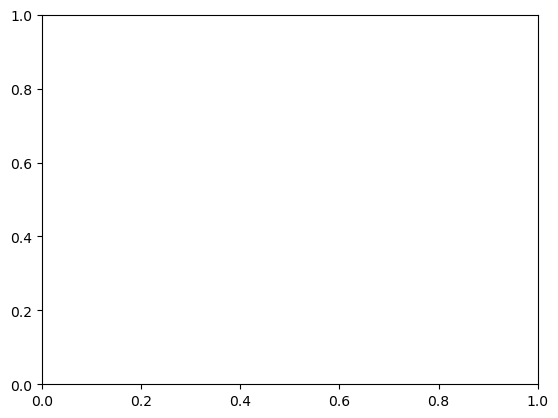

In [16]:
from scipy.integrate import solve_ivp #ivp stands for initial value problem

m = 1.0
c = 0.5
k = 4.0
F = 1

t = np.linspace(0,10,1000)

def model(t,y):
    x,v = y
    dxdt = v 
    dvdt = (1/m)*(F - c*v - k*x)
    return [dxdt, dvdt]


sol = solve_ivp(model, [0,10],[0,0],t_eval = t) #you need the model, the range (0 to 10), and the last bit i dk 
#by default, it uses range/kutta 4th/5th order

plt.plot(t,T,label = "Analytical") #as the dt beomes infintesimaly smaller, the closer and closer we get to the analytical line we generated previously
plt.plot(sol.t, sol.y[0], '--', label="solve_ivp") #making it dotted) 
plt.legend()
plt.title("Analytical vs Numerical") 


In [ ]:
## Attempted Corrected Version due to previous error: RC Circuit Example (using Dr. Martins's Website as a refference) 

In [2]:
# Numerical Solution
R = 1000      # ohms
C = 0.001     # farads
Vin = 5       # step input
V0 = 0
t = np.linspace(0, 5, 200) #I am not sure why it is requiring np to be defined - looking at earlier code it did not make this complaint 

# Analytical Solution
tau = R*C
V = Vin + (V0 - Vin) * np.exp(-t/(tau)) # solution is given for now

# Numerical Solution
def rc_model(t, V):
    return (Vin - V) / (R * C)

from scipy.integrate import solve_ivp

sol = solve_ivp(rc_model, [0, 5], [V0], t_eval=t)

plt.plot(t, V, label="Analytical")
plt.plot(sol.t, sol.y[0], '--', label="solve_ivp")
plt.title("RC Circuit Response")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.show()

AttributeError: 'int' object has no attribute 'linspace'